# Nested CV: Pearson r per fold (LOIO)

This notebook loads three result files:
- `outputs/nested_cv/nested_cv_loio_gcn_summary.json`
- `outputs/nested_cv/nested_cv_nograph_results.json`
- `outputs/nested_cv/nested_cv_loio_ensemble_gcn_results.json`

It then visualizes the per-fold Pearson correlation for each side by side in the same figure. The loader supports multiple JSON schemas (legacy and new).

In [320]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import MultipleLocator
from pathlib import Path
from typing import List, Dict, Tuple, Any, Optional

# Robust parser ...

In [321]:
BOXPLOT_STYLE = {
    "font.family": "serif",
    "font.serif": ["CMU Serif", "Computer Modern Roman", "DejaVu Serif"],
    "mathtext.fontset": "cm",
    "axes.titleweight": "normal",
    "axes.titlepad": 14,
    "axes.labelsize": 13,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
}


In [322]:
def plot_phenotype_single_axis(
    panel_specs: List[Dict[str, Any]],
    title: str,
    outfile: Optional[str] = None,
    figsize: Tuple[float, float] = (12.5, 5.5),
    grid_step: Optional[float] = 0.1,
    label_step: Optional[float] = None,
) -> None:
    """Render one figure with phenotypes on the x-axis and model boxes as hue."""

    rows: List[Dict[str, Any]] = []
    label_sequence: List[str] = []
    phenotype_order: List[str] = []
    for spec in panel_specs:
        phenotype = spec.get("panel_label") or spec.get("title")
        if phenotype is None:
            continue
        phenotype_order.append(phenotype)
        for res in spec.get("results", []):
            label = res["label"]
            if label not in label_sequence:
                label_sequence.append(label)
            values = res["df"].get("pearson_r")
            if values is None:
                continue
            for val in values:
                rows.append({"Phenotype": phenotype, "Model": label, "Correlation": val})

    if not rows:
        raise ValueError("No data available to plot.")

    long_df = pd.DataFrame(rows)
    hue_order = [label for label in LABEL_ORDER if label in long_df["Model"].unique()]
    missing = [label for label in label_sequence if label not in hue_order]
    hue_order.extend(missing)
    palette = [LABEL_COLOR_MAP.get(label, "#a0a0a0") for label in hue_order]

    label_step = label_step if label_step is not None else grid_step

    with plt.rc_context(BOXPLOT_STYLE):
        fig, ax = plt.subplots(figsize=figsize, constrained_layout=True)
        sns.boxplot(
            data=long_df,
            x="Phenotype",
            y="Correlation",
            hue="Model",
            order=phenotype_order,
            hue_order=hue_order,
            palette=palette,
            linewidth=1.1,
            fliersize=4.0,
            ax=ax,
        )

        ax.set_title(title, fontsize=18)
        ax.set_xlabel("")
        ax.set_ylabel("Correlation", fontsize=14)
        ax.set_facecolor("#fdfdfd")
        for spine in ax.spines.values():
            spine.set_visible(False)

        if label_step:
            ax.yaxis.set_major_locator(MultipleLocator(label_step))
        if grid_step:
            ax.yaxis.set_minor_locator(MultipleLocator(grid_step))
            if not np.isclose(grid_step, label_step or grid_step):
                ax.tick_params(axis="y", which="minor", length=0)
        ax.tick_params(axis="y", which="major", length=4)

        grid_kwargs = dict(axis="y", linestyle=":", linewidth=0.9, color="#b9b9b9", alpha=0.9)
        ax.grid(which="major", **grid_kwargs)
        if grid_step and not np.isclose(grid_step, label_step or grid_step):
            ax.grid(which="minor", **grid_kwargs)

        handles, labels = ax.get_legend_handles_labels()
        legend_labels = [lbl.replace(" ", "\n") if " " in lbl else lbl for lbl in labels]
        ax.legend(
            handles=handles,
            labels=legend_labels,
            frameon=False,
            loc="center left",
            bbox_to_anchor=(1.01, 0.5),
            borderaxespad=0.6,
            prop={"size": 11},
        )

        if outfile:
            fig.savefig(outfile, dpi=300, bbox_inches="tight")
            print(f"Saved figure to {outfile}")
        plt.show()

# Across population

## Tarsus Length

In [ ]:
labels = ['MLP', 'GCN', 'GraphSAGE', 'MLP Ensemble', 'GraphSAGE Ensemble', 'GBLUP']
base_path = '../outputs/nested_cv/thr_tarsus/loio'
labels_path = {'MLP': f'{base_path}/mlp_results.json',
               'GCN': f'{base_path}/gcn_results.json',
               'GraphSAGE': f'{base_path}/sage_results.json',
               'MLP Ensemble': f'{base_path}/mlp_ens_results.json',
               'GraphSAGE Ensemble': f'{base_path}/ens_sage_results.json',
                'GCN Inductive': f'{base_path}/gcn_inductive_results.json',
                'GraphSAGE Inductive': f'{base_path}/sage_inductive_results.json',
               'GBLUP': f'{base_path}/gblup_aase_results.json'}

loio_results = load_many(labels_path)
# Show heads for sanity
[ (r['label'], r['df'].head()) for r in loio_results ]

[('MLP',
     fold  pearson_r
  0     1   0.299649
  1     2   0.327693
  2     3   0.236379
  3     4   0.285372
  4     5   0.231031),
 ('GCN',
     fold  pearson_r
  0     1   0.337562
  1     2   0.321279
  2     3   0.224257
  3     4   0.321721
  4     5   0.204368),
 ('GraphSAGE',
     fold  pearson_r
  0     1   0.259259
  1     2   0.404182
  2     3   0.197616
  3     4   0.272427
  4     5   0.256181),
 ('MLP Ensemble',
     fold  pearson_r
  0     1   0.328396
  1     2   0.247521
  2     3   0.217832
  3     4   0.254469
  4     5   0.217187),
 ('GraphSAGE Ensemble',
     fold  pearson_r
  0     1   0.314988
  1     2   0.279527
  2     3   0.209347
  3     4   0.319256
  4     5   0.180348),
 ('GCN Inductive',
     fold  pearson_r
  0     1   0.200483
  1     2   0.330070
  2     3   0.174740
  3     4   0.293885
  4     5   0.215191),
 ('GraphSAGE Inductive',
     fold  pearson_r
  0     1   0.235413
  1     2   0.435629
  2     3   0.219629
  3     4   0.289640
  4     

## Body Mass

In [ ]:
labels_body = ['MLP', 'GCN', 'GraphSAGE', 'MLP Ensemble', 'GCN Ensemble', 'GraphSAGE Ensemble', 'GBLUP']
base_path_body = '../outputs/nested_cv/body_mass/loio'
labels_path_body = {
    'MLP': f'{base_path_body}/mlp_results.json',
    'GCN': f'{base_path_body}/gcn_results.json',
    'GraphSAGE': f'{base_path_body}/sage_results.json',
    'MLP Ensemble': f'{base_path_body}/mlp_ens_results.json',
    'GraphSAGE Ensemble': f'{base_path_body}/ens_sage_results.json',
    'GCN Inductive': f'{base_path_body}/gcn_inductive_results.json',
    'GraphSAGE Inductive': f'{base_path_body}/sage_inductive_results.json',
    'GBLUP': f'{base_path_body}/gblup_aase_results.json',
}

loio_results_body = load_many(labels_path_body)
# Show heads for sanity
[ (r['label'], r['df'].head()) for r in loio_results_body ]

[('MLP',
     fold  pearson_r
  0     1   0.201026
  1     2   0.388593
  2     3   0.149661
  3     4   0.174978
  4     5   0.104949),
 ('GCN',
     fold  pearson_r
  0     1   0.251862
  1     2   0.205945
  2     3   0.161535
  3     4   0.209417
  4     5   0.061864),
 ('GraphSAGE',
     fold  pearson_r
  0     1     0.2448
  1     2     0.3718
  2     3     0.1737
  3     4     0.2310
  4     5     0.1153),
 ('MLP Ensemble',
     fold  pearson_r
  0     1   0.255356
  1     2   0.317215
  2     3   0.186943
  3     4   0.213236
  4     5   0.134819),
 ('GraphSAGE Ensemble',
     fold  pearson_r
  0     1   0.228669
  1     2   0.453528
  2     3   0.158698
  3     4   0.215068
  4     5   0.173397),
 ('GCN Inductive',
     fold  pearson_r
  0     1   0.185367
  1     2   0.383662
  2     3   0.167795
  3     4   0.185808
  4     5   0.102896),
 ('GraphSAGE Inductive',
     fold  pearson_r
  0     1   0.231871
  1     2   0.444149
  2     3   0.161150
  3     4   0.203354
  4     

## Wing length

In [ ]:
labels_wing = ['No graph', 'GCN', 'GraphSAGE', 'GBLUP']
base_path_wing = '../outputs/nested_cv/thr_wing/loio'
labels_path_wing = {
    'MLP Ensemble': f'{base_path_wing}/mlp_ens_results.json',
    'GraphSAGE Ensemble': f'{base_path_wing}/ens_sage_results.json',
    'MLP': f'{base_path_wing}/mlp_results.json',
    'GCN': f'{base_path_wing}/gcn_results.json',
    'GraphSAGE': f'{base_path_wing}/sage_results.json',
    'GCN Inductive': f'{base_path_wing}/gcn_inductive_results.json',
    'GraphSAGE Inductive': f'{base_path_wing}/sage_inductive_results.json',
    'GBLUP': f'{base_path_wing}/gblup_aase_results.json',
}

loio_results_wing = load_many(labels_path_wing)
# Show heads for sanity
[ (r['label'], r['df'].head()) for r in loio_results_wing ]

[('MLP Ensemble',
     fold  pearson_r
  0     1   0.167837
  1     2   0.174907
  2     3   0.247334
  3     4   0.337966
  4     5   0.116599),
 ('GraphSAGE Ensemble',
     fold  pearson_r
  0     1   0.200911
  1     2   0.177614
  2     3   0.252920
  3     4   0.370401
  4     5   0.109210),
 ('MLP',
     fold  pearson_r
  0     1   0.194766
  1     2   0.227563
  2     3   0.243119
  3     4   0.357564
  4     5   0.098402),
 ('GCN',
     fold  pearson_r
  0     1   0.155661
  1     2   0.229653
  2     3   0.251189
  3     4   0.311960
  4     5   0.122658),
 ('GraphSAGE',
     fold  pearson_r
  0     1   0.218713
  1     2   0.241346
  2     3   0.261488
  3     4   0.302767
  4     5   0.077877),
 ('GCN Inductive',
     fold  pearson_r
  0     1   0.113015
  1     2   0.291049
  2     3   0.217260
  3     4   0.340328
  4     5   0.082905),
 ('GraphSAGE Inductive',
     fold  pearson_r
  0     1   0.162758
  1     2   0.284800
  2     3   0.231892
  3     4   0.322981
  4     

Saved figure to figures/loio_single_panel.pdf


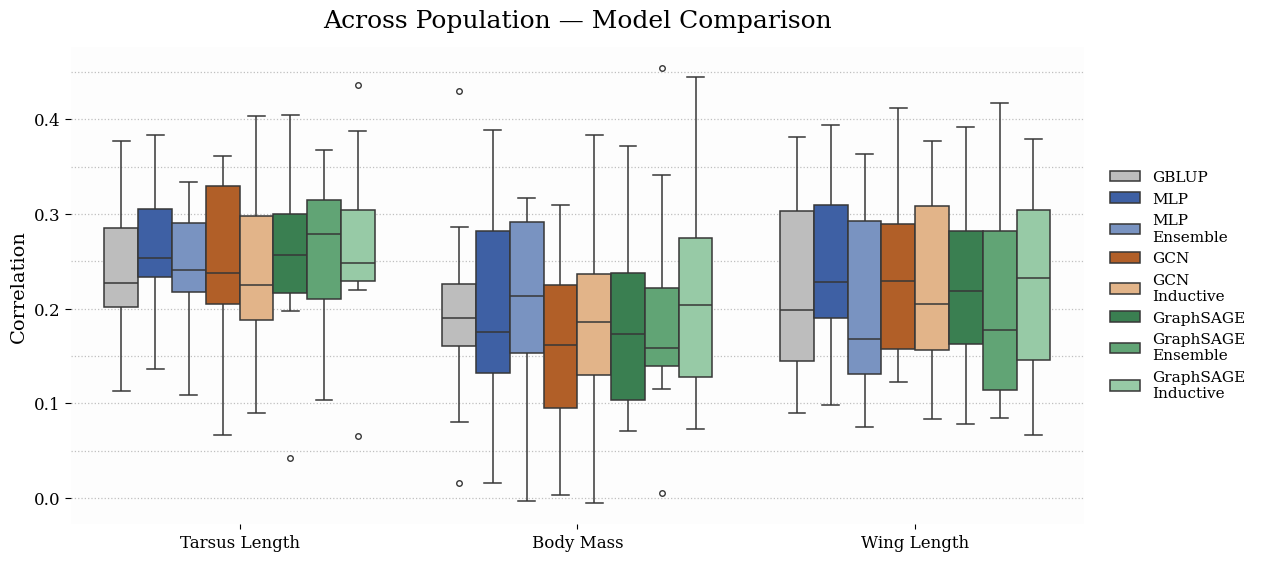

In [ ]:
loio_panel_specs = [
    {
        "panel_label": "Tarsus Length",
        "results": loio_results,
    },
    {
        "panel_label": "Body Mass",
        "results": loio_results_body,
    },
    {
        "panel_label": "Wing Length",
        "results": loio_results_wing,
    },
]

plot_phenotype_single_axis(
    loio_panel_specs,
    title="Across Population — Model Comparison",
    outfile="../figures/loio_single_panel.pdf",
    figsize=(12.5, 5.5),
    grid_step=0.05,
    label_step=0.1,
)


In [ ]:
# Export Across Population (LOIO) figure data to CSV
rows = []
for spec in loio_panel_specs:
    phenotype = spec.get("panel_label")
    for res in spec.get("results", []):
        model_label = res["label"]
        values = res["df"].get("pearson_r")
        if values is not None:
            for idx, val in enumerate(values):
                fold_id = res["df"].get("fold", [idx] * len(values))[idx] if "fold" in res["df"] else idx + 1
                rows.append({
                    "phenotype": phenotype,
                    "model": model_label,
                    "fold": fold_id,
                    "pearson_r": val
                })

loio_export_df = pd.DataFrame(rows)
loio_export_df = loio_export_df.sort_values(["phenotype", "model", "fold"])

# Save raw data
csv_path = "../statistics/across_population_raw_data.csv"
loio_export_df.to_csv(csv_path, index=False, float_format='%.4f')
print(f"Saved across population raw data to {csv_path}")

# Create summary statistics
summary_stats = []
for phenotype in loio_export_df["phenotype"].unique():
    for model in loio_export_df["model"].unique():
        subset = loio_export_df[
            (loio_export_df["phenotype"] == phenotype) & 
            (loio_export_df["model"] == model)
        ]["pearson_r"]
        
        if len(subset) > 0:
            summary_stats.append({
                "phenotype": phenotype,
                "model": model,
                "mean": subset.mean(),
                "std": subset.std(),
                "min": subset.min(),
                "q25": subset.quantile(0.25),
                "median": subset.median(),
                "q75": subset.quantile(0.75),
                "max": subset.max(),
                "count": len(subset)
            })

summary_df = pd.DataFrame(summary_stats)
summary_df = summary_df.sort_values(["phenotype", "model"])

summary_path = "../statistics/across_population_summary.csv"
summary_df.to_csv(summary_path, index=False, float_format='%.4f')
print(f"Saved across population summary statistics to {summary_path}")

display(summary_df)

Saved across population raw data to across_population_raw_data.csv
Saved across population summary statistics to across_population_summary.csv


,phenotype,model,mean,std,min,q25,median,q75,max,count
0,Body Mass,GBLUP,0.196945,0.106832,0.015600,0.160900,0.190000,0.225500,0.430000,11
1,Body Mass,GCN,0.156706,0.099582,0.003366,0.095305,0.161535,0.225323,0.309790,11
2,Body Mass,GCN Inductive,0.186785,0.109104,-0.004816,0.130100,0.185367,0.236188,0.383662,11
3,Body Mass,GraphSAGE,0.187522,0.103322,0.070700,0.103657,0.173700,0.237900,0.371800,11
4,Body Mass,GraphSAGE Ensemble,0.193090,0.119145,0.005193,0.139230,0.158698,0.221869,0.453528,11
5,Body Mass,GraphSAGE Inductive,0.214700,0.111270,0.072408,0.127965,0.203354,0.274911,0.444149,11
6,Body Mass,MLP,0.198305,0.108152,0.015911,0.132312,0.174978,0.281890,0.388593,11
7,Body Mass,MLP Ensemble,0.210049,0.098093,-0.003235,0.153478,0.213236,0.291211,0.317215,11
8,Tarsus Length,GBLUP,0.241218,0.078942,0.112500,0.202200,0.227200,0.285250,0.377000,11
9,Tarsus Length,GCN,0.247334,0.102005,0.066308,0.205098,0.237670,0.329642,0.361284,11


## Export Across Population data to CSV

# Within population

## Tarsus Length

In [ ]:
labels_tarsus = ['MLP', 'GCN', 'GraphSAGE', 'GBLUP']
base_path_tarsus = '../outputs/nested_cv/thr_tarsus/within'
labels_path_tarsus = {
    'MLP': f'{base_path_tarsus}/mlp_results.json',
    'GCN': f'{base_path_tarsus}/gcn_results.json',
    'GraphSAGE': f'{base_path_tarsus}/sage_results.json',
    'GraphSAGE Inductive': f'{base_path_tarsus}/sage_inductive_results.json',
    'GBLUP': f'{base_path_tarsus}/gblup_aase_results.json'}

loio_results_tarsus = load_many(labels_path_tarsus)
# Show heads for sanity
[ (r['label'], r['df'].head()) for r in loio_results_tarsus ]

[('MLP',
     fold  pearson_r
  0     1   0.374905
  1     2   0.376610
  2     3   0.384919
  3     4   0.439546
  4     5   0.395727),
 ('GCN',
     fold  pearson_r
  0     1   0.358692
  1     2   0.333765
  2     3   0.352946
  3     4   0.459282
  4     5   0.355328),
 ('GraphSAGE',
     fold  pearson_r
  0     1   0.399630
  1     2   0.352287
  2     3   0.394229
  3     4   0.439601
  4     5   0.388039),
 ('GraphSAGE Inductive',
     fold  pearson_r
  0     1   0.361538
  1     2   0.356916
  2     3   0.351367
  3     4   0.439865
  4     5   0.378899),
 ('GBLUP',
     fold  pearson_r
  0     1     0.4615
  1     2     0.4154
  2     3     0.3249
  3     4     0.3976
  4     5     0.4096)]

## Body Mass

In [ ]:
labels_mass = ['MLP ', 'GCN', 'GraphSAGE', 'GBLUP']
base_path_mass = '../outputs/nested_cv/body_mass/within'
labels_path_mass = {
    'MLP': f'{base_path_mass}/mlp_results.json',
    'GCN': f'{base_path_mass}/gcn_results.json',
    'GraphSAGE Inductive': f'{base_path_mass}/sage_inductive_results.json',
    'GraphSAGE': f'{base_path_mass}/sage_results.json',
    'GBLUP': f'{base_path_mass}/gblup_aase_results.json'}

loio_results_mass = load_many(labels_path_mass)
# Show heads for sanity
[ (r['label'], r['df'].head()) for r in loio_results_mass ]

[('MLP',
     fold  pearson_r
  0     1   0.377075
  1     2   0.241012
  2     3   0.262173
  3     4   0.336322
  4     5   0.349502),
 ('GCN',
     fold  pearson_r
  0     1   0.383969
  1     2   0.223055
  2     3   0.238698
  3     4   0.307276
  4     5   0.343003),
 ('GraphSAGE Inductive',
     fold  pearson_r
  0     1   0.352199
  1     2   0.275535
  2     3   0.225282
  3     4   0.304621
  4     5   0.319077),
 ('GraphSAGE',
     fold  pearson_r
  0     1   0.383870
  1     2   0.257241
  2     3   0.207926
  3     4   0.320078
  4     5   0.297683),
 ('GBLUP',
     fold  pearson_r
  0     1     0.3468
  1     2     0.2346
  2     3     0.2704
  3     4     0.3016
  4     5     0.3087)]

## Wing length

In [ ]:
labels_wing_within = ['MLP', 'GBLUP']
base_path_wing_within = '../outputs/nested_cv/thr_wing/within'
labels_path_wing_within = {
    'MLP': f'{base_path_wing_within}/mlp_results.json',
    'GBLUP': f'{base_path_wing_within}/gblup_aase_results.json',
    'GCN': f'{base_path_wing_within}/gcn_results.json',
    'GraphSAGE': f'{base_path_wing_within}/sage_results.json',
    'GraphSAGE Inductive': f'{base_path_wing_within}/sage_inductive_results.json'}
loio_results_wing = load_many(labels_path_wing_within)
# Show heads for sanity
[ (r['label'], r['df'].head()) for r in loio_results_wing ]

[('MLP',
     fold  pearson_r
  0     1   0.312110
  1     2   0.239171
  2     3   0.349187
  3     4   0.395027
  4     5   0.292721),
 ('GBLUP',
     fold  pearson_r
  0     1     0.3136
  1     2     0.2430
  2     3     0.3848
  3     4     0.4743
  4     5     0.2968),
 ('GCN',
     fold  pearson_r
  0     1   0.307291
  1     2   0.270440
  2     3   0.322288
  3     4   0.383682
  4     5   0.334491),
 ('GraphSAGE',
     fold  pearson_r
  0     1   0.282446
  1     2   0.246495
  2     3   0.312443
  3     4   0.349600
  4     5   0.297398),
 ('GraphSAGE Inductive',
     fold  pearson_r
  0     1   0.283733
  1     2   0.252835
  2     3   0.343828
  3     4   0.385522
  4     5   0.307858)]

Saved figure to figures/within_single_panel.pdf


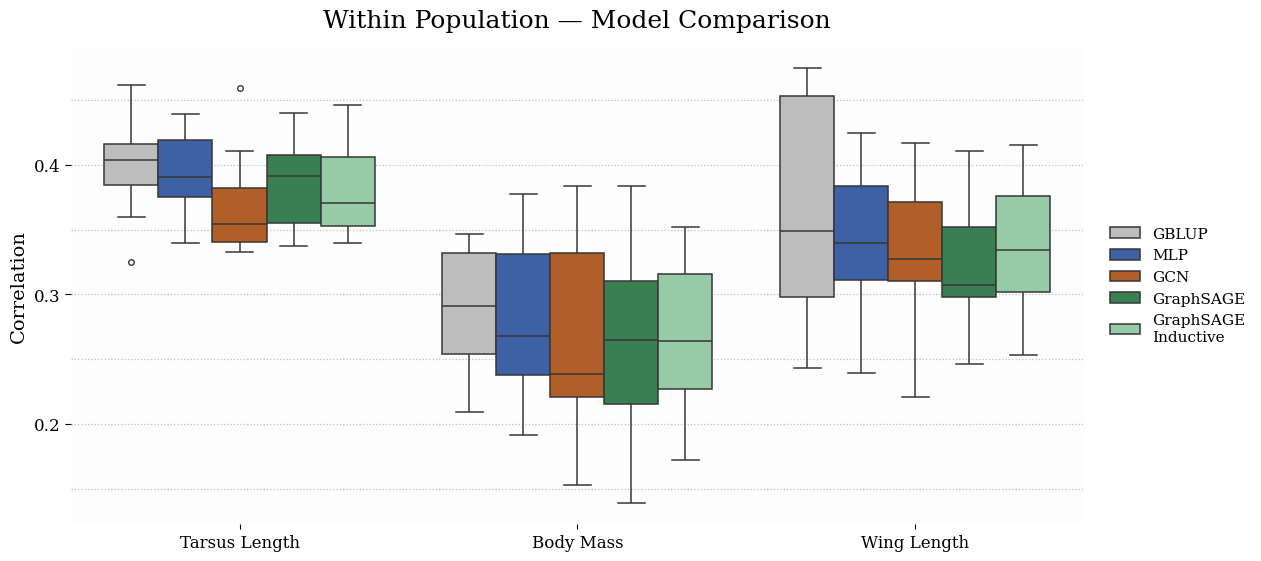

In [ ]:
within_panel_specs = [
    {
        "panel_label": "Tarsus Length",
        "results": loio_results_tarsus,
    },
    {
        "panel_label": "Body Mass",
        "results": loio_results_mass,
    },
    {
        "panel_label": "Wing Length",
        "results": loio_results_wing,
    },
]

plot_phenotype_single_axis(
    within_panel_specs,
    title="Within Population — Model Comparison",
    outfile="../figures/within_single_panel.pdf",
    figsize=(12.5, 5.5),
    grid_step=0.05,
    label_step=0.1,
)


In [ ]:
# Export Within Population figure data to CSV
rows = []
for spec in within_panel_specs:
    phenotype = spec.get("panel_label")
    for res in spec.get("results", []):
        model_label = res["label"]
        values = res["df"].get("pearson_r")
        if values is not None:
            for idx, val in enumerate(values):
                fold_id = res["df"].get("fold", [idx] * len(values))[idx] if "fold" in res["df"] else idx + 1
                rows.append({
                    "phenotype": phenotype,
                    "model": model_label,
                    "fold": fold_id,
                    "pearson_r": val
                })

within_export_df = pd.DataFrame(rows)
within_export_df = within_export_df.sort_values(["phenotype", "model", "fold"])

# Save raw data
csv_path = "../statistics/within_population_raw_data.csv"
within_export_df.to_csv(csv_path, index=False, float_format='%.4f')
print(f"Saved within population raw data to {csv_path}")

# Create summary statistics
summary_stats = []
for phenotype in within_export_df["phenotype"].unique():
    for model in within_export_df["model"].unique():
        subset = within_export_df[
            (within_export_df["phenotype"] == phenotype) & 
            (within_export_df["model"] == model)
        ]["pearson_r"]
        
        if len(subset) > 0:
            summary_stats.append({
                "phenotype": phenotype,
                "model": model,
                "mean": subset.mean(),
                "std": subset.std(),
                "min": subset.min(),
                "q25": subset.quantile(0.25),
                "median": subset.median(),
                "q75": subset.quantile(0.75),
                "max": subset.max(),
                "count": len(subset)
            })

summary_df = pd.DataFrame(summary_stats)
summary_df = summary_df.sort_values(["phenotype", "model"])

summary_path = "../statistics/within_population_summary.csv"
summary_df.to_csv(summary_path, index=False, float_format='%.4f')
print(f"Saved within population summary statistics to {summary_path}")

display(summary_df)

Saved within population raw data to within_population_raw_data.csv
Saved within population summary statistics to within_population_summary.csv


,phenotype,model,mean,std,min,q25,median,q75,max,count
0,Body Mass,GBLUP,0.288030,0.047727,0.209000,0.253900,0.291200,0.332175,0.346800,10
1,Body Mass,GCN,0.266554,0.072749,0.152721,0.221004,0.238248,0.332030,0.383969,10
2,Body Mass,GraphSAGE,0.260748,0.072977,0.139303,0.215040,0.264691,0.310118,0.383870,10
3,Body Mass,GraphSAGE Inductive,0.270298,0.059573,0.171939,0.227134,0.263709,0.315463,0.352199,10
4,Body Mass,MLP,0.277936,0.064515,0.191120,0.237383,0.268026,0.331290,0.377075,10
5,Tarsus Length,GBLUP,0.400810,0.039772,0.324900,0.384425,0.403600,0.415700,0.461500,10
6,Tarsus Length,GCN,0.367393,0.040872,0.332942,0.340062,0.354137,0.382443,0.459282,10
7,Tarsus Length,GraphSAGE,0.385551,0.034826,0.337470,0.354778,0.391134,0.407472,0.439601,10
8,Tarsus Length,GraphSAGE Inductive,0.382711,0.038185,0.339385,0.353111,0.370219,0.406170,0.446166,10
9,Tarsus Length,MLP,0.393303,0.032823,0.339803,0.375331,0.390323,0.419177,0.439546,10


## Export Within Population data to CSV